In [193]:
import numpy as np
np.set_printoptions(precision=2)
import matplotlib.pyplot as plt

The purpose of this notebook is to code a gradient decent for single perceptron and validate the results

In [297]:
# f is a function whose solutons represents points on a circle with radius 5 and origin (0, 0)
f = lambda X1, X2: (X1**2) + (X2**2) - 25 

# if you plot the points X1**2 and X2**2 then that will be a straight line.

In [298]:
# lets first create few actual solutions which will serve as out training data
# sx = np.linspace(-5, 5, 100)
# solution = lambda x: np.sqrt(25 - x**2)
# sy = solution(sx)

# generate few points outside the circle
ex = np.linspace(-5, 5, 50)
ey = np.linspace(-5, 5, 50)
np.random.shuffle(ex)
np.random.shuffle(ey)

# Xs = np.concatenate((sx, sx, ex))
# Ys = np.concatenate((sy, -sy, ey))
# randomize correct and incorrect solution space (input space)
zipped = np.array(list(zip(ex, ey)))
np.random.shuffle(zipped)

In [299]:
X1 = zipped[:, 0]
X2 = zipped[:, 1]
Y = f(X1, X2)

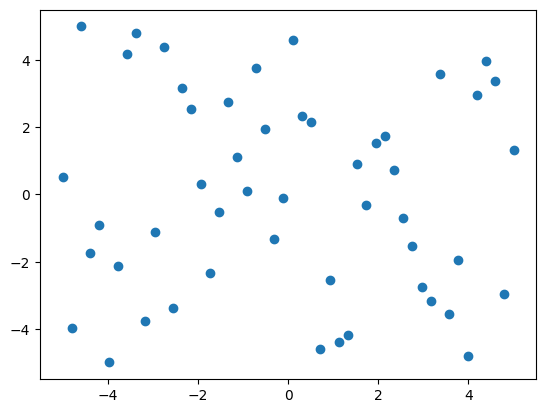

In [300]:
fig, ax = plt.subplots()
ax.scatter(X1, X2)
plt.show()

In [199]:
# now lets imagine that we have the list of inputs and corresponding outputs of an unknown problem. 
# But we know that the problem is linearly seperable, ie the solutions can be seperated by means of a line 
# (need not be a straight line). This asuumption can be taken becaue we have 2 dimensional input therefore 
# the problem space is in a 2D plane.
# For these inputs to produce the desired outputs we can design a neron as follows.
# perceptron = w0 * x1 + w1 * x2 + b
# here w0, w1 and b are unknows
# based on the output we can classify the points as 0, 1 or 2.



In [200]:
# But how do we validate that the network produces correct output ? We can take the diff of the neuron output and 
# actual output. Which will be the difference or loss value for our input. To make it a +ve value lets take the square
# of the difference. So the loss square will be our loss function.

# The next step is to identify how much each of the weights and bias influence the loss square function. For this we take the 
# derivative of loss square function with respect to each of w0, w1 and bias.

In [301]:
# lets start with random weights and bias for out percepron
weights = np.random.randn(2)
b = np.ones(1)
loss = lambda X1,X2,Y: ((weights[0] * X1 + weights[1] * X2 + b) - Y)
square_loss = lambda X1,X2,Y: loss(X1,X2,Y)**2
d_loss_wrt_w0 = lambda X1,X2,Y: 2 * loss(X1,X2,Y) * x1
d_loss_wrt_w1 = lambda X1,X2,Y: 2 * loss(X1,X2,Y) * x2
d_loss_wrt_b = lambda X1,X2,Y: 2 * loss(X1,X2,Y)

In [302]:
for i in range(10000):
    lr = 0.001
    lossess = []
    grad_w0_a = []
    grad_w1_a = []
    grad_b_a = []
    
    np.random.shuffle(zipped)
    X1 = zipped[:, 0]
    X2 = zipped[:, 1]
    Y = f(X1, X2)
    rand_range = 100 #np.random.randint(50, 100)
    
    for (x1,x2,y) in zip(X1[:rand_range]**2,X2[:rand_range]**2,Y[:rand_range]):
        l = square_loss(x1,x2,y)
        lossess.append(l)
        grad_w0 = d_loss_wrt_w0(x1,x2,y)
        grad_w1 = d_loss_wrt_w1(x1,x2,y)
        grad_b = d_loss_wrt_b(x1,x2,y)
        grad_w0_a.append(grad_w0)
        grad_w1_a.append(grad_w1)
        grad_b_a.append(grad_b)
    if (i%1000 == 0):
        print("Iteration=", i + 1, "Weights:", weights, "Bias:", b, "loss:", np.average(lossess))
    
    weights = weights - lr * np.array([np.average(grad_w0_a).item(), np.average(grad_w1_a).item()])
    b = b - lr * np.average(grad_b_a)

Iteration= 1 Weights: [0.15 2.32] Bias: [1.] loss: 1030.2507548642989
Iteration= 1001 Weights: [0.47 0.47] Bias: [-11.44] loss: 59.656797039455476
Iteration= 2001 Weights: [0.72 0.72] Bias: [-17.91] loss: 16.3395053126089
Iteration= 3001 Weights: [0.86 0.86] Bias: [-21.29] loss: 4.475255915670542
Iteration= 4001 Weights: [0.92 0.92] Bias: [-23.06] loss: 1.225735732359587
Iteration= 5001 Weights: [0.96 0.96] Bias: [-23.98] loss: 0.3357189206369803
Iteration= 6001 Weights: [0.98 0.98] Bias: [-24.47] loss: 0.09195064702623328
Iteration= 7001 Weights: [0.99 0.99] Bias: [-24.72] loss: 0.025184524817665713
Iteration= 8001 Weights: [0.99 0.99] Bias: [-24.85] loss: 0.0068978339011688105
Iteration= 9001 Weights: [1. 1.] Bias: [-24.92] loss: 0.0018892598876732627


$$
f(x) = \int_{-\infty}^{\infty} e^{-x^2} dx
$$